In [10]:
import pandas as pd
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
df_st=pd.read_csv('result/card_result_propostion.txt', header=0,index_col=0, sep='\t')
change_loc=pd.read_csv('results/ST_location_simulate.txt',sep='\t',header=0,index_col=0)

label_simulate=pd.read_csv('results/label_simulate.txt',sep='\t',header=0,index_col=0)

In [13]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def compute_avg_neighbor_distance(loc, X, n_neighbors=10):
    """
    Compute for each spot the average distance (Euclidean) in cell-type proportion
    between the spot and its n_neighbors nearest neighbors in space.

    Parameters:
    loc : np.ndarray, shape (N, 2)
        Spatial coordinates of spots.
    X : np.ndarray, shape (N, D)
        Cell-type proportion matrix for each spot (D cell types).
    n_neighbors : int, default 10
        Number of nearest neighbors to consider.

    Returns:
    avg_distances : np.ndarray, shape (N,)
        Average distance for each spot.
    """
    N = loc.shape[0]
    # Find nearest neighbors (excluding self)
    nn = NearestNeighbors(n_neighbors=n_neighbors+1, metric='euclidean')
    nn.fit(loc)
    distances, indices = nn.kneighbors(loc)  # indices shape (N, n_neighbors+1), first is self

    # Exclude self (first column)
    neighbor_indices = indices[:, 1:]  # (N, n_neighbors)
    # neighbor_distances = distances[:, 1:]  # not needed

    avg_distances = np.zeros(N)
    for i in range(N):
        neighbors_X = X[neighbor_indices[i]]  # shape (n_neighbors, D)
        # Compute Euclidean distance between X[i] and each neighbor row
        diff = X[i] - neighbors_X  # broadcasting
        dists = np.linalg.norm(diff, axis=1)  # (n_neighbors,)
        avg_distances[i] = np.mean(dists)
    return avg_distances

In [14]:
loc=change_loc.values
X=df_st.values
avg_prop = compute_avg_neighbor_distance(loc, X, n_neighbors=10)

AUROC (ROC 曲线下面积): 0.7517
AUPR  (PR 曲线下面积): 0.1776


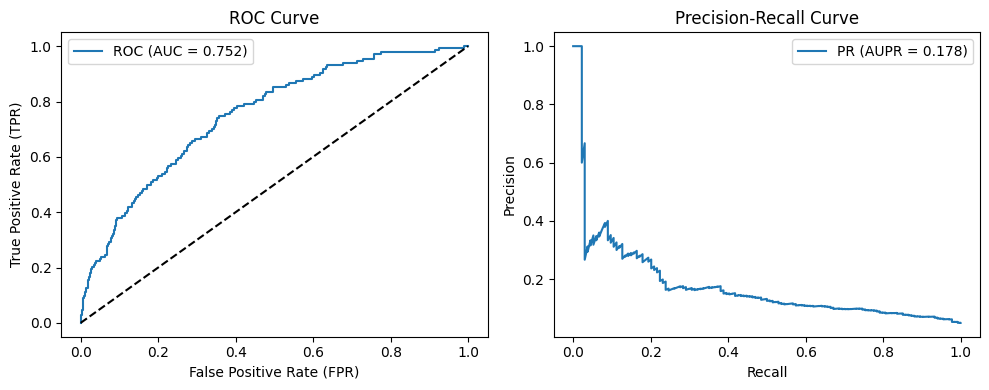

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


scores =  avg_prop
labels = label_simulate['Abberant'].values   

fpr, tpr, thresholds_roc = roc_curve(labels, scores)
auroc = auc(fpr, tpr)


precision, recall, thresholds_pr = precision_recall_curve(labels, scores)
# average_precision_score 
aupr = average_precision_score(labels, scores)
print(f"AUROC (ROC 曲线下面积): {auroc:.4f}")
print(f"AUPR  (PR 曲线下面积): {aupr:.4f}")

plt.figure(figsize=(10, 4))

# ROC 
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'ROC (AUC = {auroc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()

# PR 
plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f'PR (AUPR = {aupr:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()




In [ ]:
import pandas as pd
df_roc = pd.DataFrame({'fpr': fpr, 'tpr': tpr, 'threshold': thresholds_roc})
df_roc.to_csv('metrics/CARD_ROC.txt', sep='\t', index=False)

precision_adj = precision[:-1]
recall_adj = recall[:-1]
df_pr = pd.DataFrame({'precision': precision_adj, 'recall': recall_adj, 'threshold': thresholds_pr})
df_pr.to_csv('metrics/CARD_PR.txt', sep='\t', index=False)